In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import seaborn as sns
import os
from graph_tool.all import *
import scipy as sp
import sklearn
from tqdm import tqdm
from scipy.interpolate import make_smoothing_spline

import imageio
import os
import shutil

# Multiple simulations analysis

In [37]:
def read_file(fname, thr_len=0):
    data = []
    with open(fname) as f:
        for x in f:
            line = np.array([float(n) for n in x.split(", ")])
            if len(line)>thr_len:
                data.append(line)
    return data

In [38]:
def normalize(c,r,mu,mI,mO,mS,mHK,mu0,r0):
    mu_c = [np.array([(m-mu0*(1-t))/t for (m,t) in zip(mu[i],c[i])]) for i in range(len(c))]
    r_c = [np.array([(m-r0*(1-t))/t for (m,t) in zip(r[i],c[i])]) for i in range(len(c))]
    mI_c = [np.array([(m*(1-t))/t for (m,t) in zip(mI[i],c[i])]) for i in range(len(c))]
    mO_c = [np.array([(m*(1-t))/t for (m,t) in zip(mO[i],c[i])]) for i in range(len(c))]
    mS_c = [np.array([(m*(1-t))/t for (m,t) in zip(mS[i],c[i])]) for i in range(len(c))]
    mHK_c = [np.array([(m*(1-t))/t for (m,t) in zip(mHK[i],c[i])]) for i in range(len(c))]
    return r_c,mu_c,mI_c,mO_c,mS_c,mHK_c

In [39]:
def stats_elementwise(vs):
    """
    Compute element-wise mean and standard deviation across uneven-length sequences,
    ignoring out-of-range indices and NaNs.

    Parameters
    ----------
    vs : list of array-like
        A list of sequences (lists or numpy arrays) of possibly different lengths.

    Returns
    -------
    means : numpy.ndarray
        Array of length max(len(v) for v in vs) containing the mean at each position.
    stds : numpy.ndarray
        Array of same length containing the standard deviation at each position.
    """
    # Determine the maximum length
    n = max(len(v) for v in vs)
    
    # Preallocate results
    means = np.empty(n, dtype=float)
    stds = np.empty(n, dtype=float)
    
    for i in range(n):
        # Collect valid values at position i
        vals = [v[i] for v in vs if i < len(v) and not np.isnan(v[i])]
        
        if vals:
            arr = np.array(vals, dtype=float)
            means[i] = arr.mean()
            stds[i] = arr.std(ddof=0)  # population std; use ddof=1 for sample std
        else:
            means[i] = np.nan
            stds[i] = np.nan
            
    return means, stds

In [5]:
### Data loading ###
####################

idx = 17
c0 = read_file("../Data/CancerEvo/"+str(idx)+"_c.txt")
r = read_file("../Data/CancerEvo/"+str(idx)+"_r.txt")
mu = read_file("../Data/CancerEvo/"+str(idx)+"_mu.txt")
mI = read_file("../Data/CancerEvo/"+str(idx)+"_I.txt")
mO = read_file("../Data/CancerEvo/"+str(idx)+"_O.txt")
mS = read_file("../Data/CancerEvo/"+str(idx)+"_S.txt")
mHK = read_file("../Data/CancerEvo/"+str(idx)+"_HK.txt")
states = []
for c in c0:
    np.nan_to_num(c,0)
    if c[-1]>0.49:
        states.append("Tumor")
    else:
        states.append("Health")
states = np.array(states)
#np.loadtxt("../Data/CancerEvo/"+str(idx)+"_state.txt", dtype=str)
#r_c0,mu_c0,mI_c0,mO_c0,mS_c0,mHK_c0 = normalize(c0,r,mu,mI,mO,mS,mHK,mu0,r0)

map_h = np.where(states=="Health")[0]
map_t = np.where(states=="Tumor")[0]
map_d = np.where(states=="Done")[0]

print(f"Probability health: {len(map_h)/len(states)}")
print(f"Probability tumor: {len(map_t)/len(states)}")
print(f"Probability done: {len(map_d)/len(states)}")

Probability health: 0.62
Probability tumor: 0.38
Probability done: 0.0


In [ ]:
#### mu vs r progression in time ###
_,ax = plt.subplots(1,2,figsize=(12,5))

r_tum = np.concat([r[i] for i in map_t])
mu_tum = np.concat([mu[i] for i in map_t])

sns.kdeplot(x=r_tum, y=mu_tum, fill=True, thresh=0.02, cmap="viridis", ax=ax[1])
ax[1].set_facecolor("k")
ax[1].set_xlim([0.15,0.41])
ax[1].set_xlabel("r", fontsize=20)
ax[1].set_ylim([0.005, 0.047])
ax[1].set_ylabel(r"$\mu$", fontsize=20)
plt.tight_layout()

ax[0].scatter(rs, mus, c=cm.coolwarm(np.linspace(0,1,len(rs))), alpha=1)

ax[0].set_xlim([0.15,0.41])
ax[0].set_xlabel("r", fontsize=20)
ax[0].set_ylim([0.005, 0.047])
ax[0].set_ylabel(r"$\mu$", fontsize=20)
plt.tight_layout()

In [ ]:
### Average Mutation progression ###
####################################

plt.subplots(1,2,figsize=(12,5))

# Tumor #
plt.subplot(1,2,1)

y, yerr  = stats_elementwise([mI[i] for i in map_t])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='cyan', label='I')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='cyan')

y, yerr  = stats_elementwise([mO[i] for i in map_t])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='red', label='O')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='red')

y, yerr  = stats_elementwise([mS[i] for i in map_t])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='green', label='S')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='green')

y, yerr  = stats_elementwise([mHK[i] for i in map_t])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='purple', label='HK')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='purple')

y, yerr  = stats_elementwise([c0[i] for i in map_t])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='gold', label='Tumor size')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='gold')

plt.title("Tumor", fontsize=15)
plt.xlabel('Time', fontsize=15)
plt.ylabel('Average', fontsize=15)
plt.legend(fontsize=12)

###################################################################################

# Health #
plt.subplot(1,2,2)

y, yerr  = stats_elementwise([mI[i] for i in map_h])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='cyan', label='I')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='cyan')

y, yerr  = stats_elementwise([mO[i] for i in map_h])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='red', label='O')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='red')

y, yerr  = stats_elementwise([mS[i] for i in map_h])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='green', label='S')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='green')

y, yerr  = stats_elementwise([mHK[i] for i in map_h])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='purple', label='HK')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='purple')

y, yerr  = stats_elementwise([c0[i] for i in map_h])
ci_half_width = yerr
x = np.arange(len(y))
plt.plot(x, y, color='gold', label='Tumor size')
plt.fill_between(x,y-ci_half_width,y + ci_half_width,alpha=0.3,color='gold')

plt.title("Health", fontsize=15)
plt.xlabel('Time', fontsize=15)
plt.ylabel('Average', fontsize=15)
plt.ylim([-0.05, 1.05])
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


# Analytics

## Phase diagram

In [52]:
def dyn_state(r,r0,mu,k,N):
    return r/r0, (1-(1-mu)**(2*k*N)*(1-mu**2)**(N*(1-2*k)))

In [102]:
### Data on phase diagram ###

r_prop_list = np.array([1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0])
results = np.array([-0.6101874390439277, 0.6226682669930774, 1.2917773010287472, 1.8387745389776091, 2.2434712898547584, 2.660774128739252, 2.9356429157955044, 3.1821620335205547, 3.4130647650803505, 3.625270864316522, 3.8084414875435573])
p_die_data = np.array([(1-(1-m*1e-2)**(10)) for m in results])

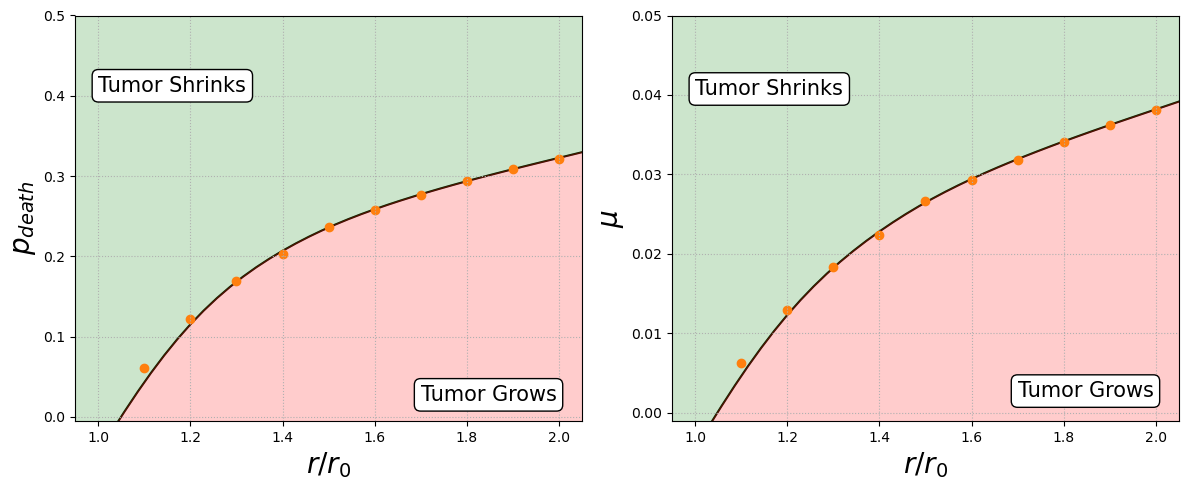

In [10]:
#### PHASE DIAGRAM PLOT ####
############################

r0=2e-1
N=10
_,ax = plt.subplots(1,2,figsize=(12,5))

spl = make_smoothing_spline(r_prop_list, p_die_data, lam=0.001)
x_new = np.linspace(0.8,2.2,50)
ax[0].plot(x_new, spl(x_new), color="k", zorder=0)
ax[0].fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
ax[0].fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")
ax[0].scatter(r_prop_list, p_die_data, color="C1")

spl = make_smoothing_spline(r_prop_list, results*1e-2, lam=0.001)
x_new = np.linspace(0.8,2.2,50)
ax[1].plot(x_new, spl(x_new), color="k", zorder=0)
ax[1].fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
ax[1].fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")
ax[1].scatter(r_prop_list, results*1e-2, color="C1")

[axi.set_xlabel(r"$r/r_0$", fontsize=20) for axi in ax]
[axi.set_xlim([0.95,2.05]) for axi in ax]
ax[0].set_ylim([-0.005,0.5])
ax[1].set_ylim([-0.001,0.05])
ax[0].text(1,0.405,"Tumor Shrinks", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
ax[0].text(1.7,0.02,"Tumor Grows", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
ax[1].text(1,0.04,"Tumor Shrinks", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
ax[1].text(1.7,0.002,"Tumor Grows", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
ax[0].set_ylabel(r"$p_{death}$", fontsize=20)
ax[1].set_ylabel(r"$\mu$", fontsize=20)

#plt.legend()
[axi.grid(ls=":") for axi in ax]
plt.tight_layout()

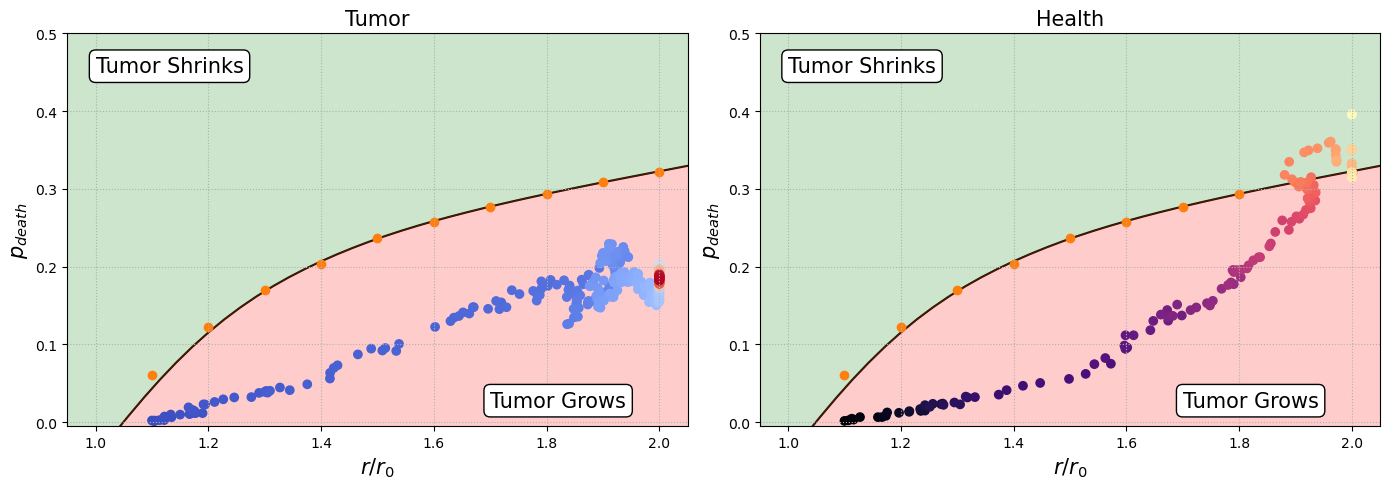

In [19]:
#### Tumor vs Health progression ####
#####################################

r0=2e-1
N=10
_,ax = plt.subplots(1,2,figsize=(14,5))
spl = make_smoothing_spline(r_prop_list, p_die_data, lam=0.001)
x_new = np.linspace(0.8,2.2,50)
ax[0].plot(x_new, spl(x_new), color="k", zorder=0)
ax[0].fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
ax[0].fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")
ax[0].scatter(r_prop_list, p_die_data, color="C1")
ax[1].plot(x_new, spl(x_new), color="k", zorder=0)
ax[1].fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
ax[1].fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")
ax[1].scatter(r_prop_list, p_die_data, color="C1")

points = np.array([dyn_state(r=r, r0=r0, mu=mu, k=k, N=N) for r,mu,k in zip(r[map_t[12]],mu[map_t[12]],mHK[map_t[12]])])
ax[0].scatter(*points.T, c=cm.coolwarm(np.linspace(0,1,len(points))), label="Tumor")
points = np.array([dyn_state(r=r, r0=r0, mu=mu, k=k, N=N) for r,mu,k in zip(r[map_h[7]],mu[map_h[7]],mHK[map_h[7]])])
ax[1].scatter(*points.T, c=cm.magma(np.linspace(0,1,len(points))), label="Health")

[axi.set_xlabel(r"$r/r_0$", fontsize=15) for axi in ax]
[axi.set_ylabel(r"$p_{death}$", fontsize=15) for axi in ax]
[axi.set_xlim([0.95,2.05]) for axi in ax]
[axi.set_ylim([-0.005,0.5]) for axi in ax]
#plt.legend()
[axi.grid(ls=":") for axi in ax]
ax[0].set_title("Tumor", fontsize=15)
ax[1].set_title("Health", fontsize=15)
#plt.colorbar(imh, label="Progression")
#plt.colorbar(imt)
[axi.text(1,0.45,"Tumor Shrinks", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15) for axi in ax]
[axi.text(1.7,0.02,"Tumor Grows", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15) for axi in ax]
plt.tight_layout()
#plt.savefig("../CancerEvo/images/diag_2traj_0.png")

In [ ]:
"""
rs_1 = np.loadtxt("../Data/CancerEvo/single/r_1.txt")
mus_1 = np.loadtxt("../Data/CancerEvo/single/m_1.txt")
k_1 = np.loadtxt("../Data/CancerEvo/single/k_1.txt")
t_1 = np.loadtxt("../Data/CancerEvo/single/t_1.txt")

rs_2 = np.loadtxt("../Data/CancerEvo/single/r_2.txt")
mus_2 = np.loadtxt("../Data/CancerEvo/single/m_2.txt")
k_2 = np.loadtxt("../Data/CancerEvo/single/k_2.txt")
t_2 = np.loadtxt("../Data/CancerEvo/single/t_2.txt")

rs_3 = np.loadtxt("../Data/CancerEvo/single/r_3.txt")
mus_3 = np.loadtxt("../Data/CancerEvo/single/m_3.txt")
k_3 = np.loadtxt("../Data/CancerEvo/single/k_3.txt")
t_3 = np.loadtxt("../Data/CancerEvo/single/t_3.txt")

rs = np.concatenate([rs,rs_1,rs_2,rs_3])
mus = np.concatenate([mus,mus_1,mus_2,mus_3])
k = np.concatenate([k,k_1,k_2,k_3])
t = np.concatenate([t,t_1,t_2,t_3])
"""

In [169]:
#### Load Data ####
###################

rs = np.loadtxt("../Data/CancerEvo/single/r_4chr.txt")
mus = np.loadtxt("../Data/CancerEvo/single/m_4chr.txt")
k = np.loadtxt("../Data/CancerEvo/single/k_4chr.txt")
t = np.loadtxt("../Data/CancerEvo/single/t_4chr.txt")
mstd = np.loadtxt("../Data/CancerEvo/single/mstd_4chr.txt")

N_chr = 3
r0 = 2e-1
N_HK = 10

savefig = True
namefig = "../CancerEvo/images/diag_3chr_1.png"

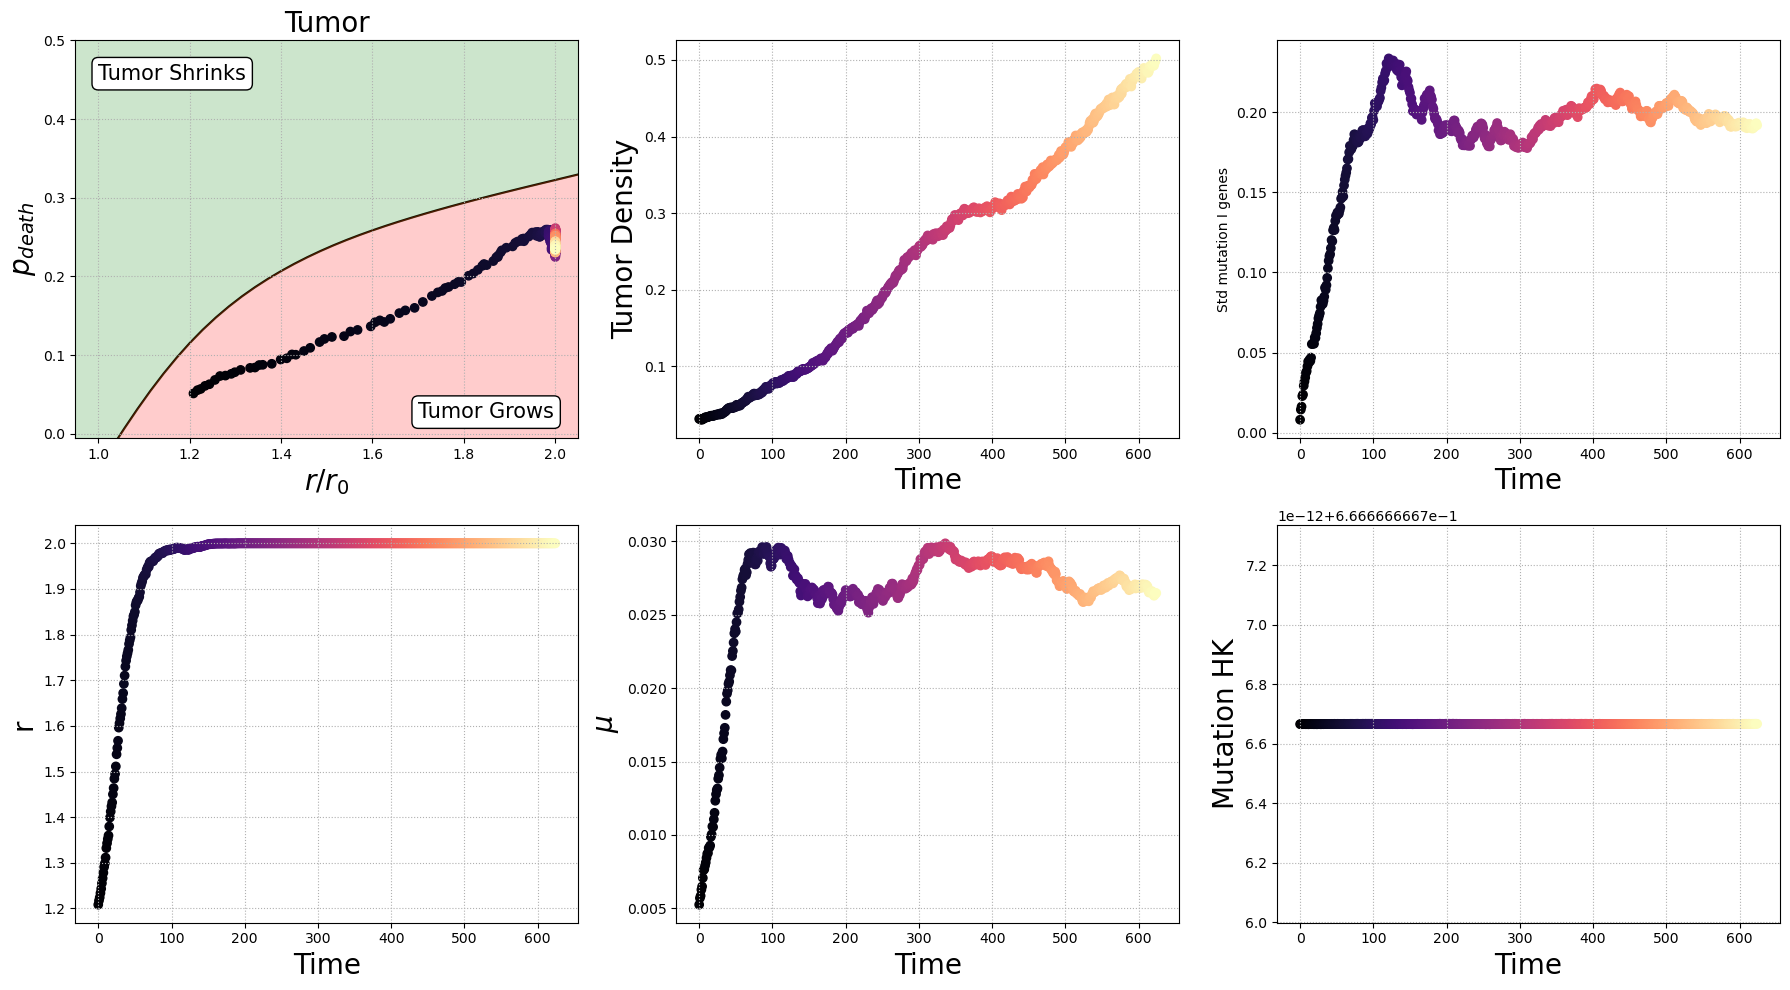

<Figure size 640x480 with 0 Axes>

In [170]:
#### Study of dynamics ####
###########################

_,ax = plt.subplots(2,3,figsize=(18,10))
ax = ax.flatten()
spl = make_smoothing_spline(r_prop_list, p_die_data, lam=0.001)
x_new = np.linspace(0.8,2.2,50)
ax[0].plot(x_new, spl(x_new), color="k", zorder=0)
ax[0].fill_between(x_new, spl(x_new),max(spl(x_new))*1.5, alpha=0.2, color="green")
ax[0].fill_between(x_new, -1, spl(x_new), alpha=0.2, color="red")

points = np.array([dyn_state(r=r, r0=r0, mu=mu, k=k*3/4, N=N_HK) for r,mu,k in zip(rs,mus,k)])
ax[0].scatter(*points.T, c=np.linspace(0,1,len(points)), cmap="magma", label="Tumor")

ax[1].scatter(np.arange(len(t)), t, c=np.arange(len(t)), cmap="magma", zorder=0)
#ax[2].scatter(np.arange(len(t)), [spl(rsi/r0)-p_d for rsi,p_d in zip(rs, points[:,1])], c=np.arange(len(t)), cmap="magma", zorder=0)
#ax[2].hlines(0,0,len(t), color="red", ls="--")
ax[2].scatter(np.arange(len(t)), mstd, c=np.arange(len(t)), cmap="magma", zorder=0)
ax[3].scatter(np.arange(len(t)), rs/r0, c=np.arange(len(t)), cmap="magma", zorder=0)
ax[4].scatter(np.arange(len(t)), mus, c=np.arange(len(t)), cmap="magma", zorder=0)
ax[5].scatter(np.arange(len(t)), k, c=np.arange(len(t)), cmap="magma", zorder=0)


fontsize = 20
ax[0].set_xlabel(r"$r/r_0$", fontsize=fontsize)
ax[0].set_ylabel(r"$p_{death}$", fontsize=fontsize)
ax[1].set_xlabel("Time", fontsize=fontsize)
ax[1].set_ylabel("Tumor Density", fontsize=fontsize)
ax[2].set_xlabel("Time", fontsize=fontsize)
#ax[2].set_ylabel(r"$p_{die,exp}-p_{die,true}$", fontsize=25)
ax[2].set_ylabel("Std mutation I genes")
ax[3].set_xlabel("Time", fontsize=fontsize)
ax[3].set_ylabel("r", fontsize=fontsize)
ax[4].set_xlabel("Time", fontsize=fontsize)
ax[4].set_ylabel(r"$\mu$", fontsize=fontsize)
ax[5].set_xlabel("Time", fontsize=fontsize)
ax[5].set_ylabel("Mutation HK", fontsize=fontsize)

ax[0].set_xlim([0.95,2.05])
ax[0].set_ylim([-0.005,0.5])
#plt.legend()
[axi.grid(ls=":") for axi in ax]
ax[0].set_title("Tumor", fontsize=fontsize)
#plt.colorbar(imh, label="Progression")
#plt.colorbar(imt)
ax[0].text(1,0.45,"Tumor Shrinks", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
ax[0].text(1.7,0.02,"Tumor Grows", bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'), fontsize=15)
plt.tight_layout()
plt.show()
if savefig:
    plt.savefig(namefig)

In [171]:
mus[-1]

np.float64(0.026467131474103595)

In [ ]:
plt.plot(np.arange(500), mus, label="Mean")
plt.plot(mstd/5, label="Std (Norm)")
plt.legend()
plt.ylim([0.02,0.031])
plt.grid(ls="--")
plt.xlabel("Time")
plt.show()

## Population dynamics study

In [40]:
counts = np.loadtxt("../Data/CancerEvo/single/counts_full_2.txt", dtype=str, delimiter="?")
counts = [np.array(ci).astype(float) for ci in[c.split(", ") for c in counts[:]]]
for i in range(100):
    counts[i] = np.append(counts[i],[0]*(10-len(counts[i])))
counts = np.array(counts)

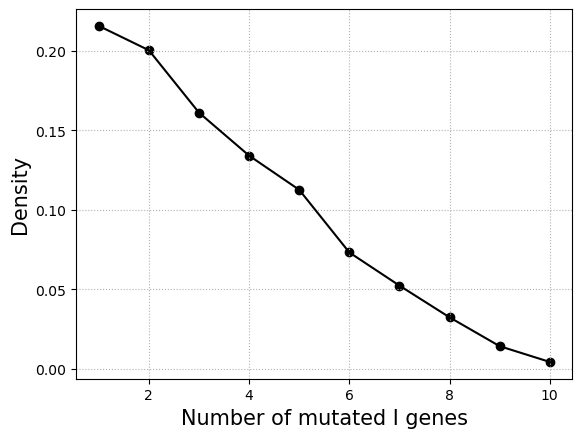

In [49]:
plt.plot(np.arange(10)+1, counts[-50], color="k")
plt.scatter(np.arange(10)+1, counts[-50], color="k")
plt.grid(ls=":")
plt.xlabel("Number of mutated I genes", fontsize=15)
plt.ylabel("Density", fontsize=15)
plt.savefig("images/pop_distr.png")

In [28]:
os.mkdir("../Data/CancerEvo/gif")
plt.ioff()
for i in tqdm(range(1000)):
    plt.figure(figsize=(7,4))
    plt.plot(counts[i])
    plt.ylim([0,0.24])
    plt.grid()
    plt.title(str(i))
    plt.scatter(np.arange(10),counts[i])
    plt.savefig(f"../Data/CancerEvo/gif/aa{i}.png")

100%|███████████████████████████████████████| 1000/1000 [01:04<00:00, 15.50it/s]


In [ ]:
#plt.errorbar(np.arange(5), np.mean(counts,axis=0)-np.mean(counts,axis=0), yerr=np.std(counts,axis=0), capsize=10)

In [ ]:
sns.heatmap((counts-np.mean(counts,axis=0)).T, cmap="coolwarm")
plt.xlabel("Time")
#plt.xticks(np.arange(0,100,10), labels=np.arange(0,100,10))
plt.ylabel("# mutated I genes")
plt.yticks(np.arange(0,5), labels=np.arange(1,6))
plt.tight_layout()
#plt.savefig("images/haetmap_pop_1.png")

In [ ]:
plt.plot(counts[:,:5])
plt.grid()
plt.show()

In [ ]:
plt.figure(figsize=(12,5))
for i,c in enumerate(counts[:-1]):
    plt.plot(np.arange(12), (c-np.mean(counts,axis=0)), label=str(i))
#plt.legend()
#plt.ylim([2,3.1])
plt.grid()

### Transitions

In [13]:
counts = np.loadtxt("../Data/CancerEvo/transitions/counts_1.txt", dtype=str, delimiter="?")
counts = np.array([np.array(ci).astype(float) for ci in[c.split(", ") for c in counts]])

In [14]:
combins = [(1,2),(1,3),(2,3),(2,4),(3,4),(3,5),(4,5),(1,444),(2,444),(3,444),(4,444),(5,444),(1,666),(2,666),(3,666),(4,666),(5,666)]
flux = np.loadtxt("../Data/CancerEvo/transitions/flux_1.txt", dtype=str, delimiter="?")
flux = np.array([np.array(ci).astype(float) for ci in[c.split(", ") for c in flux]])

In [ ]:
counts[0][combins[i][0]-1]

In [27]:
norm_flux = np.array([np.array([flux[j][i]/counts[j][combins[i][0]-1] for i in range(len(flux[0]))]) for j in range(len(flux))])

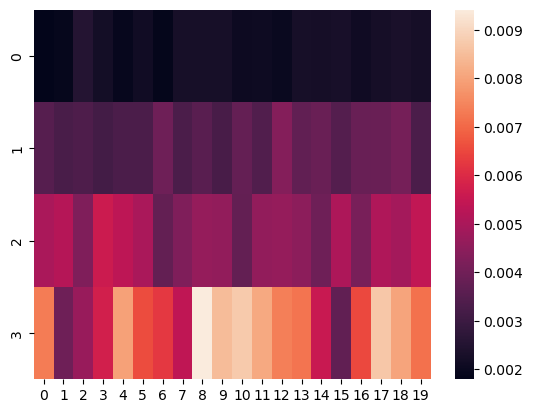

In [35]:
sns.heatmap((norm_flux[:,[0,2,4,6]]).T)
#plt.yticks(np.arange(flux.shape[1]), combins, rotation=0)
plt.show()

In [ ]:
plt.plot(np.mean(flux[:,-5:],axis=0))

In [ ]:
def p1(x,r,mu):
    return r*x[0]-mu-(1-x[0])-r(1-x[0])*x[0]

# Old

In [ ]:
# 1) enable interactive notebook backend
%matplotlib widget

from matplotlib import cm
ax = plt.figure(figsize=(10,10)).add_subplot(projection='3d')

idx = 0
#for i in map_t:
#        ax.scatter(mO[i], mHK[i], c0[i], zdir='z', label='points in (x, z)', c = cm.coolwarm(np.linspace(0,1,len(c0[i]))))

for i in map_h:
        ax.scatter(mO[i], mHK[i], c0[i], zdir='z', label='points in (x, z)', c = cm.viridis(np.linspace(0,1,len(c0[i]))))
    
ax.set_xlabel('r')
ax.set_ylabel(r'$\mu$')
ax.set_zlabel('c')
ax.view_init(elev=45., azim=80, roll=0)

plt.show()

## Gif

In [29]:
filenames = [f"aa{i}.png" for i in range(1000)]
# Create a GIF
with imageio.get_writer('gif/prog_pop_1.gif', mode='I', duration=0.5) as writer:
    for filename in filenames:
        image = imageio.v2.imread("../Data/CancerEvo/gif/"+filename)
        writer.append_data(image)

# Remove the image files for filename in filenames:
shutil.rmtree('../Data/CancerEvo/gif')